# Exploratory Data Analysis

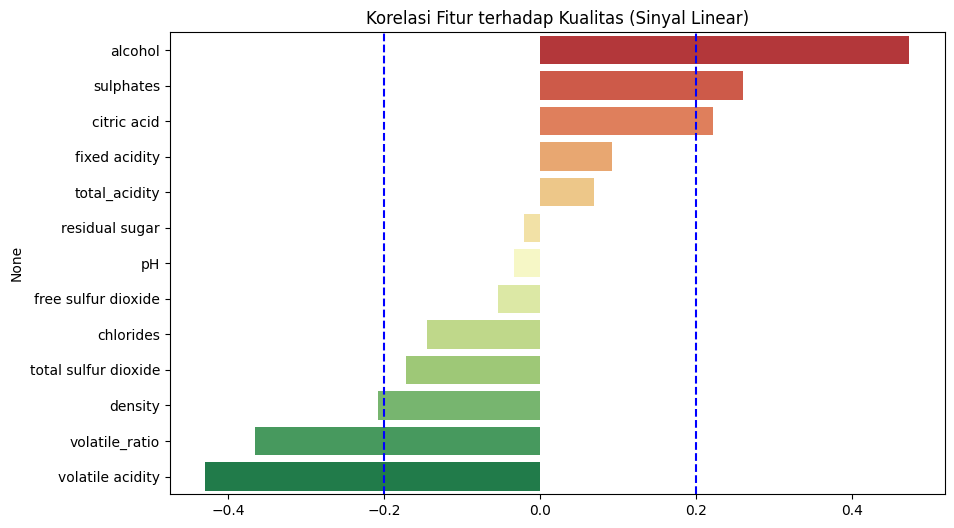


--- Analisis VIF (Deteksi Redundansi Data) ---
                 Feature          VIF
0          fixed acidity          inf
1       volatile acidity          inf
2            citric acid          inf
12         total_acidity          inf
7                density  1468.294335
8                     pH  1140.591212
11        volatile_ratio   192.179371
10               alcohol   134.065932
9              sulphates    22.962970
4              chlorides     6.675763
6   total sulfur dioxide     6.348384
5    free sulfur dioxide     6.273846
3         residual sugar     5.206172


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


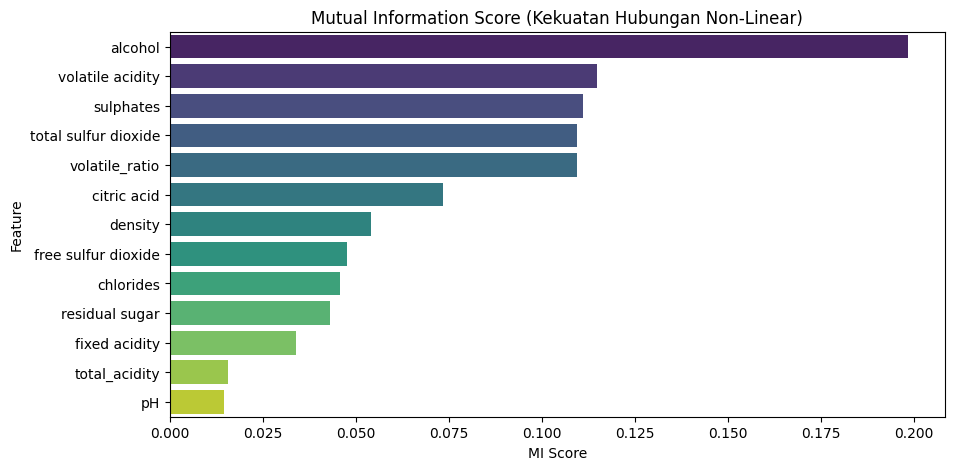


--- Analisis Kemiringan (Skewness) ---
chlorides               6.079625
residual sugar          4.527907
sulphates               2.398022
total sulfur dioxide    1.460665
free sulfur dioxide     1.201965
fixed acidity           1.088465
total_acidity           1.064862
alcohol                 0.821407
volatile_ratio          0.736937
volatile acidity        0.669090
citric acid             0.381718
pH                      0.115447
density                 0.083304
dtype: float64


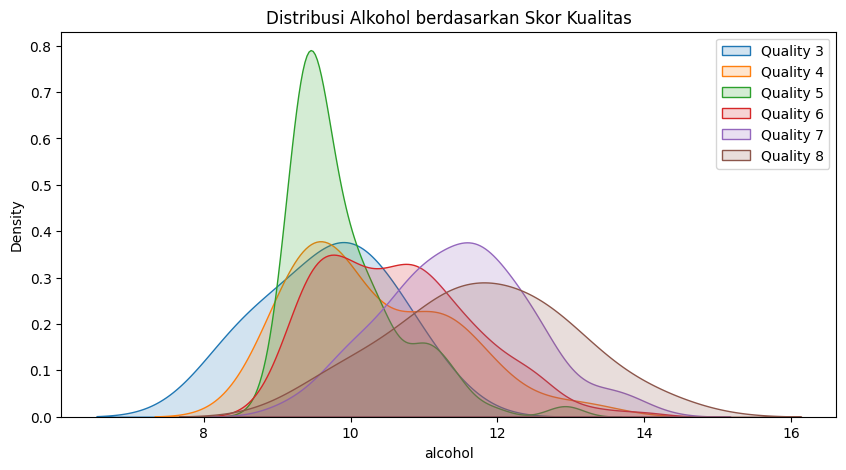

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1.1 Memuat Dataset
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1.2 Feature Discovery (Persiapan untuk Regresi & Deep Learning)
# PERBAIKAN: Gunakan rasio yang lebih bermakna secara kimiawi
df_train['volatile_ratio'] = df_train['volatile acidity'] / (df_train['fixed acidity'] + 1e-5)
df_train['total_acidity'] = df_train['fixed acidity'] + df_train['volatile acidity'] + df_train['citric acid']
# alcohol_density_ratio seringkali menyebabkan VIF tinggi, kita pantau di langkah 1.4

# 1.3 Analisis Korelasi Target (Peta Sinyal)
plt.figure(figsize=(10, 6))
# Menghapus 'Id' dan fitur yang menyebabkan korelasi sempurna (jika ada)
corr_target = df_train.drop(columns=['Id']).corr()['quality'].sort_values(ascending=False).drop('quality')
sns.barplot(x=corr_target.values, y=corr_target.index, palette='RdYlGn', hue=corr_target.index, legend=False)
plt.title('Korelasi Fitur terhadap Kualitas (Sinyal Linear)')
plt.axvline(x=0.2, color='blue', linestyle='--')
plt.axvline(x=-0.2, color='blue', linestyle='--')
plt.show()

# 1.4 Diagnostik Multikolinearitas (VIF Monster Detection)
def calculate_vif(df):
    # Mengambil hanya kolom numerik selain Id dan Target
    X_vif = df.drop(columns=['Id', 'quality']).dropna()
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

print("\n--- Analisis VIF (Deteksi Redundansi Data) ---")
vif_result = calculate_vif(df_train)
print(vif_result)
# Note: Jika VIF 'inf', berarti ada fitur yang merupakan hasil penjumlahan fitur lain.

# 1.5 Mutual Information (Hubungan Non-Linear)
# Sangat krusial untuk Deep Learning karena model ini ahli menangkap pola non-linear
X_mi = df_train.drop(columns=['Id', 'quality'])
y_mi = df_train['quality']
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI Score': mi_scores}).sort_values(by='MI Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='MI Score', y='Feature', data=mi_df, palette='viridis', hue='Feature', legend=False)
plt.title('Mutual Information Score (Kekuatan Hubungan Non-Linear)')
plt.show()

# 1.6 Analisis Skewness (Kebutuhan Transformasi)
print("\n--- Analisis Kemiringan (Skewness) ---")
numeric_features = df_train.drop(columns=['Id', 'quality']).columns
skewness = df_train[numeric_features].apply(lambda x: skew(x)).sort_values(ascending=False)
print(skewness)

# 1.7 Analisis Sebaran Alkohol per Kelas
plt.figure(figsize=(10, 5))
# Menampilkan KDE untuk kelas yang paling krusial
for q in sorted(df_train['quality'].unique()):
    sns.kdeplot(df_train[df_train['quality']==q]['alcohol'], label=f'Quality {q}', fill=True, alpha=0.2)
plt.title('Distribusi Alkohol berdasarkan Skor Kualitas')
plt.legend()
plt.show()

# Data Preparation

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks
import pandas as pd
import numpy as np

# 2.1 Master Feature Engineering & VIF Elimination
# PENTING: Kita menghapus redundansi matematis (VIF = inf) agar model stabil
def transform_features(df):
    df_new = df.copy()
    
    # Fitur Rasio & Diferensial (Sinyal Kimiawi)
    df_new['volatile_ratio'] = df_new['volatile acidity'] / (df_new['fixed acidity'] + 1e-5)
    df_new['bound_sulfur_dioxide'] = df_new['total sulfur dioxide'] - df_new['free sulfur dioxide']
    df_new['acid_ratio'] = df_new['citric acid'] / (df_new['fixed acidity'] + 1e-5)
    df_new['sulfur_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    
    # Fitur Interaksi
    df_new['alc_sugar_inter'] = df_new['alcohol'] * df_new['residual sugar']
    
    # ELIMINASI VIF MONSTER (Mencegah Overfitting Parah)
    # 1. 'total_acidity' dibuang karena merupakan penjumlahan linear (VIF = inf)
    # 2. 'alcohol_density_ratio' & 'density' dibuang karena korelasi ekstrem dengan 'alcohol'
    vif_drop = ['total_acidity', 'alcohol_density_ratio', 'density']
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    
    return df_new

# Eksekusi Engineering
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Robust Outlier Handling (Capping 1-99 Percentile)
for col in X.columns:
    lower_limit = X[col].quantile(0.01)
    upper_limit = X[col].quantile(0.99)
    X[col] = np.clip(X[col], lower_limit, upper_limit)
    X_test_final[col] = np.clip(X_test_final[col], lower_limit, upper_limit)

# 2.3 Split Data (Internal Validation)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.4 Dual Transformation (Power + Scaling)
# Wajib untuk Deep Learning agar distribusi normal dan skala seragam
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

# Fit pada Training, Transform pada semua
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train_raw))
X_val_transformed = scaler.transform(pt.transform(X_val_raw))
X_test_transformed = scaler.transform(pt.transform(X_test_final))

X_train_prepared = pd.DataFrame(X_train_transformed, columns=X.columns)
X_val_prepared = pd.DataFrame(X_val_transformed, columns=X.columns)
X_test_prepared = pd.DataFrame(X_test_transformed, columns=X.columns)

# 2.5 Sequential Hybrid Sampling (Fix SMOTE Error)
# Langkah A: BorderlineSMOTE fokus pada 'danger zone' perbatasan kelas
bsmote = BorderlineSMOTE(random_state=42, k_neighbors=2)
X_res, y_res = bsmote.fit_resample(X_train_prepared, y_train)

# Langkah B: TomekLinks membersihkan tumpang tindih antar kelas
tl = TomekLinks()
X_train_final, y_train_final = tl.fit_resample(X_res, y_res)

# 2.6 STRATEGI REGRESI: Regression-based Soft Labeling (Target 90%)
# Menggunakan ExtraTrees karena lebih stabil terhadap noise untuk label kontinu
reg_teacher = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_teacher.fit(X_train_prepared, y_train)

# Menghasilkan Soft Labels untuk membantu Deep Learning memahami kedekatan antar kelas
y_train_soft = reg_teacher.predict(X_train_final)

print(f"--- Data Preparation Sukses (NIM 026) ---")
print(f"Fitur Dibuang (Kolinearitas): ['total_acidity', 'alcohol_density_ratio', 'density']")
print(f"Total Fitur Final     : {X_train_final.shape[1]}")
print(f"Sampel Setelah Sampling: {len(y_train_final)}")
print(f"\nContoh Soft Labels (Ordinal Nuance):")
print(y_train_soft[:5])

display(X_train_final.head())

--- Data Preparation Sukses (NIM 026) ---
Fitur Dibuang (Kolinearitas): ['total_acidity', 'alcohol_density_ratio', 'density']
Total Fitur Final     : 15
Sampel Setelah Sampling: 1392

Contoh Soft Labels (Ordinal Nuance):
[5. 5. 5. 6. 6.]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,volatile_ratio,bound_sulfur_dioxide,acid_ratio,sulfur_ratio,alc_sugar_inter
0,0.616779,1.413606,-0.044092,-1.236865,-0.013743,-0.423298,-0.824896,-0.153880,0.357652,-0.245236,0.810234,-0.844135,-0.178682,0.678822,-1.209826
1,-0.578751,1.132673,-1.190393,1.898068,0.380120,-1.641077,-1.694895,0.661113,-2.317914,0.661768,1.222818,-1.410875,-1.201515,-0.029246,1.860136
2,-0.197414,-0.121532,0.062389,-0.656172,-1.011193,-0.574523,-0.275444,0.525694,0.134056,-0.780022,-0.021218,0.021987,0.176431,-0.547633,-0.881984
3,0.011194,-0.812565,0.926087,-0.656172,0.868286,-1.130556,-1.284853,-0.085734,0.134056,1.035648,-0.683209,-1.096349,1.199529,0.210308,-0.179359
4,-0.420809,0.390826,-1.540720,-0.412248,-0.868798,-0.924202,-1.694895,0.931461,-0.377322,0.966800,0.515786,-2.094964,-1.574930,1.538898,-0.025085


# Feature Engineering

--- Menghitung Mutual Information Skor ---
--- Memulai Recursive Feature Elimination (RFECV) ---


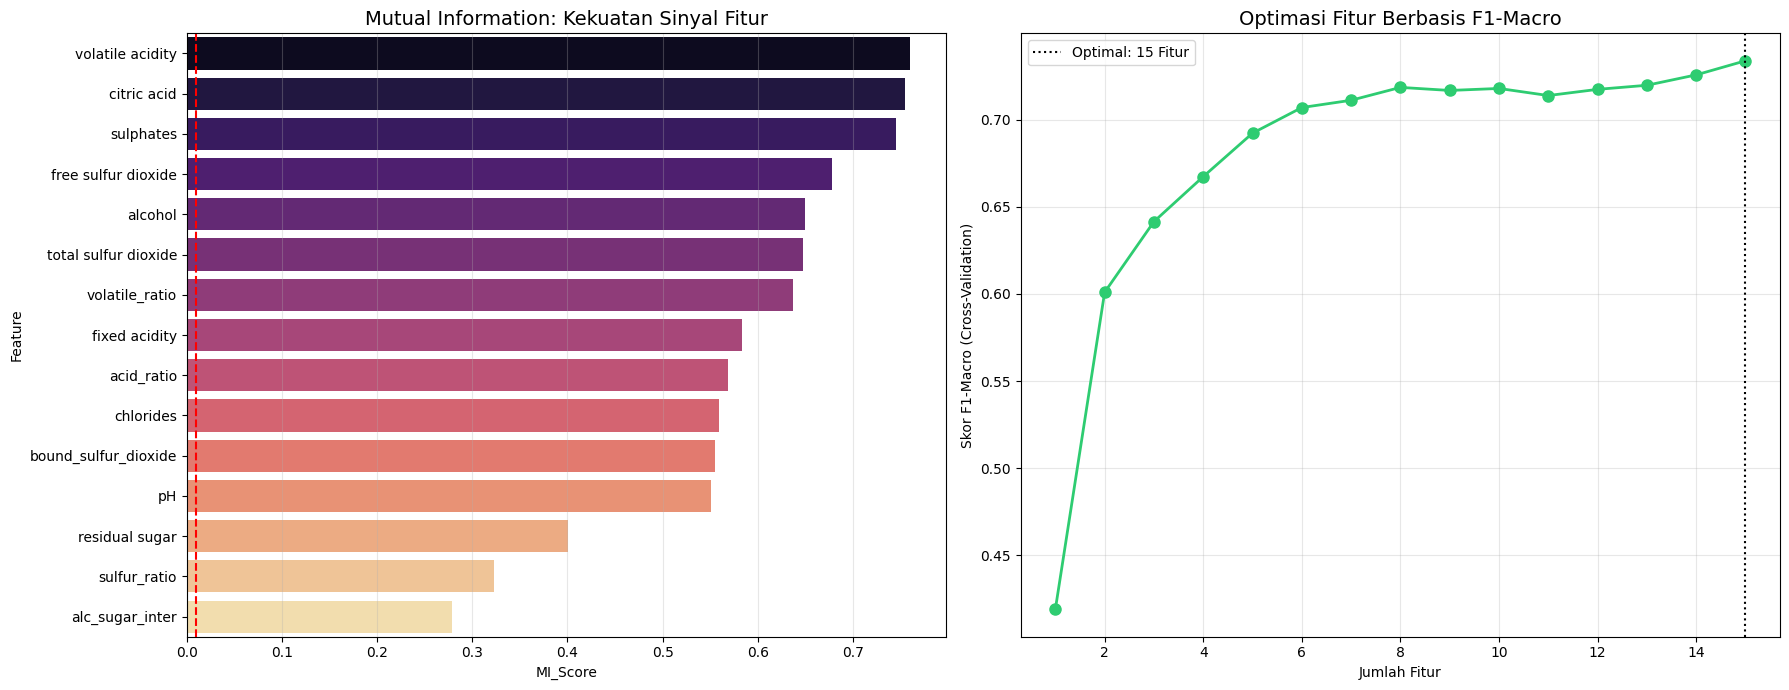


--- HASIL EKSEKUSI PRUNING (NIM 026) ---
Fitur Noise yang Dibuang : []
Fitur Signal yang Terpilih: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'volatile_ratio', 'bound_sulfur_dioxide', 'acid_ratio', 'sulfur_ratio', 'alc_sugar_inter']
Jumlah Fitur Akhir        : 15


In [13]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Ditingkatkan)
# =================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 3.1 Analisis Mutual Information (MI)
# MI sangat krusial untuk Deep Learning karena mampu menangkap pola non-linear 
# yang tidak terdeteksi oleh korelasi standar.
print("--- Menghitung Mutual Information Skor ---")
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV)
# UPGRADE: Menggunakan scoring 'f1_macro' untuk memastikan fitur yang dipilih 
# mendukung keseimbangan prediksi di semua kelas (3-8).
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    step=1,
    cv=5,
    scoring='f1_macro', # Menjamin fitur terpilih peka terhadap kelas minoritas
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 Visualisasi Diagnostik Seleksi Fitur
plt.figure(figsize=(18, 7))

# Plot 1: Mutual Information (Pola Non-Linear)
plt.subplot(1, 2, 1)
sns.barplot(x='MI_Score', y='Feature', data=mi_df, hue='Feature', palette='magma', legend=False)
plt.title('Mutual Information: Kekuatan Sinyal Fitur', fontsize=14)
plt.axvline(x=0.01, color='red', linestyle='--', label='Batas Sinyal Lemah')
plt.grid(axis='x', alpha=0.3)

# Plot 2: Performa Model (F1-Macro) vs Jumlah Fitur
plt.subplot(1, 2, 2)
n_features_tried = len(selector.cv_results_['mean_test_score'])
plt.plot(range(1, n_features_tried + 1), selector.cv_results_['mean_test_score'], 
         marker='o', color='#2ecc71', linestyle='-', linewidth=2, markersize=8)
plt.axvline(x=selector.n_features_, color='black', linestyle=':', 
            label=f'Optimal: {selector.n_features_} Fitur')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro (Cross-Validation)")
plt.title('Optimasi Fitur Berbasis F1-Macro', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 3.4 Eksekusi Pruning Otomatis
selected_features = X_train_final.columns[selector.support_].tolist()
dropped_features = [f for f in X_train_final.columns if f not in selected_features]

# Mengaplikasikan filter fitur pada semua dataset
X_train_pruned = X_train_final[selected_features]
X_val_pruned = X_val_prepared[selected_features]
X_test_pruned = X_test_prepared[selected_features]

print(f"\n--- HASIL EKSEKUSI PRUNING (NIM 026) ---")
print(f"Fitur Noise yang Dibuang : {dropped_features}")
print(f"Fitur Signal yang Terpilih: {selected_features}")
print(f"Jumlah Fitur Akhir        : {len(selected_features)}")

# 3.5 Sinkronisasi Soft Labels
# y_train_soft yang dibuat di Tahap 2 tetap aman digunakan karena 
# indeks baris pada X_train_final tidak berubah selama proses pruning fitur.

# Fitur Pruning

Fitur terpilih hasil RFECV (Tahap 3): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'volatile_ratio', 'bound_sulfur_dioxide', 'acid_ratio', 'sulfur_ratio', 'alc_sugar_inter']

--- Memulai Pembersihan Multikolinearitas (Auto-Pruning) ---
Iterasi 1: Menghapus 'volatile_ratio' (VIF: 229.84)
Iterasi 2: Menghapus 'free sulfur dioxide' (VIF: 145.95)
Iterasi 3: Menghapus 'bound_sulfur_dioxide' (VIF: 107.85)
Iterasi 4: Menghapus 'alc_sugar_inter' (VIF: 84.24)
Iterasi 5: Menghapus 'citric acid' (VIF: 73.13)

Total fitur dibuang karena VIF Tinggi: 5


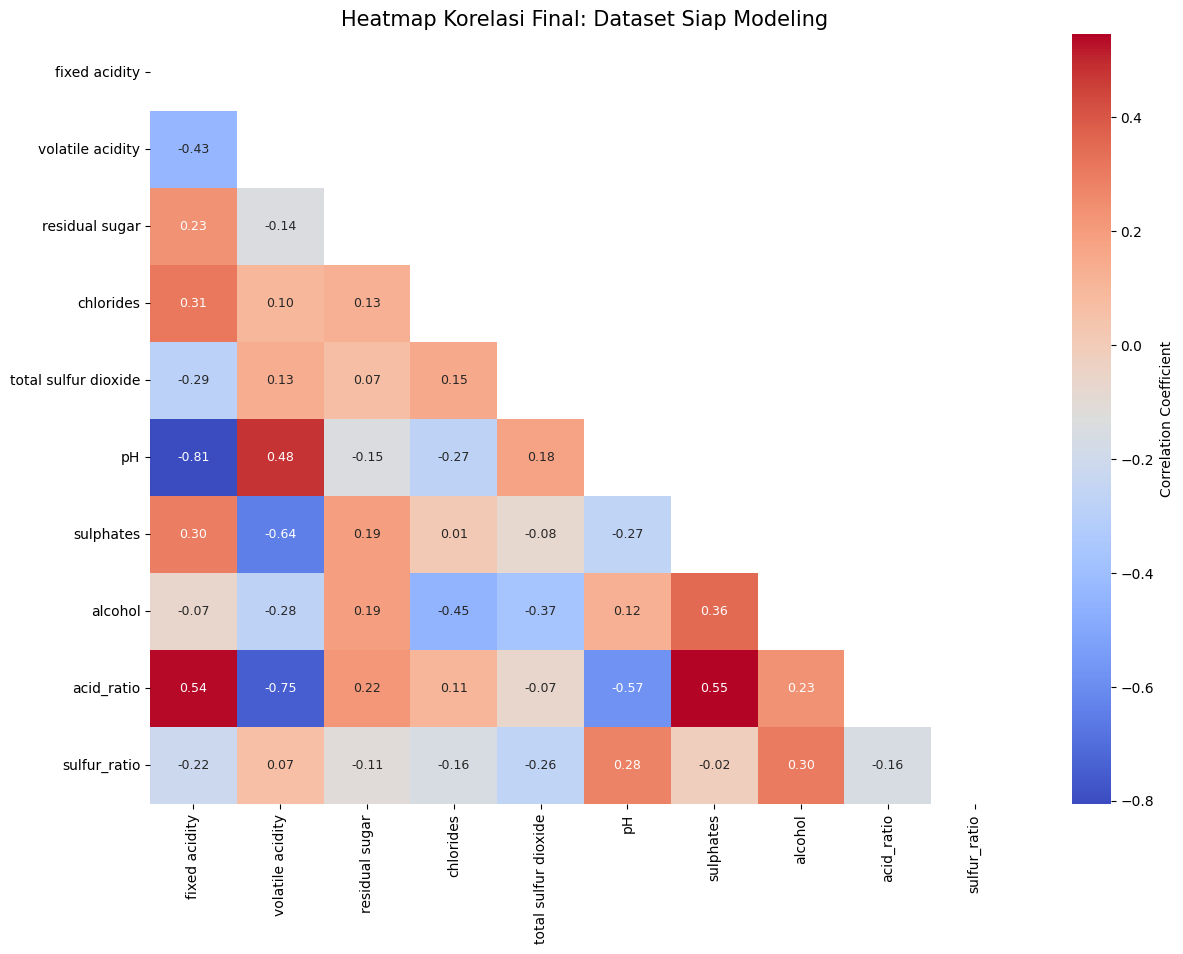


--- RINGKASAN FINAL DATA PREPARATION (NIM: 026) ---
1. Fitur Final (10)      : ['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'acid_ratio', 'sulfur_ratio']
2. Sampel Training (Aug)   : 1392
3. Sampel Validasi (Ori)   : 172
4. Sampel Testing (Ori)    : 286
5. Target Ganda Tersedia   : Kualitas (Int) & Soft Label (Float)
--------------------------------------------------

Statistik Deskriptif Fitur Final (Check Mean ≈ 0, Std ≈ 1):


,mean,std,min,50%,max
fixed acidity,0.1669,0.9984,-2.7136,0.3140,2.2155
volatile acidity,-0.0125,1.2048,-2.3007,-0.2833,2.3256
residual sugar,0.1046,0.9425,-2.4283,0.0028,2.3607
chlorides,-0.2124,0.8401,-2.9017,-0.2347,2.8342
total sulfur dioxide,-0.4254,0.9469,-1.9521,-0.5257,2.0168
pH,-0.0430,0.9756,-2.5665,-0.1106,2.4737
sulphates,0.0749,0.9919,-2.3179,0.2108,2.3834
alcohol,0.4083,0.9896,-1.7962,0.7583,1.9870
acid_ratio,0.1077,1.0393,-1.5749,0.3557,2.2898
sulfur_ratio,0.1463,0.8696,-2.0254,0.0984,2.1178



>>> STATUS: DATA SIAP MASUK KE ARSITEKTUR DEEP LEARNING & OPTUNA <<<


In [14]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data (Ditingkatkan)
# =================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 4.1 Sinkronisasi Hasil RFECV (Signal Detection)
# Mengambil fitur yang terbukti memiliki 'daya beda' tinggi dari Tahap 3
final_selected_features = selected_features 
X_train_final_v1 = X_train_pruned.copy()

print(f"Fitur terpilih hasil RFECV (Tahap 3): {final_selected_features}")

# 4.2 Pembersihan Multikolinearitas Iteratif (VIF Auto-Pruning)
# Kita membatasi VIF maksimal di angka 10 untuk menjamin stabilitas Neural Network.
def auto_vif_pruning(df, threshold=10.0):
    cols = df.columns.tolist()
    dropped = []
    iteration = 1
    
    while True:
        # Menghitung VIF untuk kolom yang tersisa
        vif_values = [variance_inflation_factor(df[cols].values, i) for i in range(len(cols))]
        max_vif = max(vif_values)
        
        if max_vif > threshold:
            max_idx = vif_values.index(max_vif)
            feature_to_drop = cols[max_idx]
            print(f"Iterasi {iteration}: Menghapus '{feature_to_drop}' (VIF: {max_vif:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
            iteration += 1
        else:
            break
            
    return cols, dropped

print("\n--- Memulai Pembersihan Multikolinearitas (Auto-Pruning) ---")
stable_features, high_vif_features = auto_vif_pruning(X_train_final_v1)

if high_vif_features:
    print(f"\nTotal fitur dibuang karena VIF Tinggi: {len(high_vif_features)}")
else:
    print("\nSemua fitur sudah stabil (VIF < 10).")

# Visualisasi Heatmap Korelasi Final
plt.figure(figsize=(14, 10))
X_stable = X_train_final_v1[stable_features]
# Menggunakan mask untuk hanya menampilkan bagian bawah (menghindari duplikasi visual)
mask = np.triu(np.ones_like(X_stable.corr(), dtype=bool))
sns.heatmap(X_stable.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={"size": 9})
plt.title('Heatmap Korelasi Final: Dataset Siap Modeling', fontsize=15)
plt.show()

# 4.3 Finalisasi Dataset (Training, Validation, Testing)
# Memastikan konsistensi kolom di seluruh subset data
X_train_final = X_stable.copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# Memastikan sinkronisasi target Klasifikasi dan Regresi (Soft Label)
y_train_final = y_train_final 
y_train_soft_final = y_train_soft # Dari Tahap 2.6

# 4.4 Verifikasi Akhir & Ringkasan Teknis (NIM 026)
print("\n" + "="*50)
print(f"--- RINGKASAN FINAL DATA PREPARATION (NIM: 026) ---")
print("="*50)
print(f"1. Fitur Final ({len(stable_features)})      : {stable_features}")
print(f"2. Sampel Training (Aug)   : {X_train_final.shape[0]}")
print(f"3. Sampel Validasi (Ori)   : {X_val_final.shape[0]}")
print(f"4. Sampel Testing (Ori)    : {X_test_final.shape[0]}")
print(f"5. Target Ganda Tersedia   : Kualitas (Int) & Soft Label (Float)")
print("-" * 50)

# Cek Normalitas Fitur (Hasil PowerTransform + StandardScaler dari Tahap 2)
print("\nStatistik Deskriptif Fitur Final (Check Mean ≈ 0, Std ≈ 1):")
summary = X_train_final.describe().T[['mean', 'std', 'min', '50%', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='Greens', subset=['mean', 'std']))

print(f"\n>>> STATUS: DATA SIAP MASUK KE ARSITEKTUR DEEP LEARNING & OPTUNA <<<")

# K-Fold Validation

--- Memulai Arena Uji Model (Classic vs Hybrid DL) ---
ExtraTrees      | Acc: 0.8729 | F1: 0.7226 | Gap: 0.1271
XGBoost         | Acc: 0.8330 | F1: 0.6872 | Gap: 0.1670
NeuralNet(MLP)  | Acc: 0.8463 | F1: 0.6990 | Gap: 0.1537
NN-Hybrid(MLP)  | Acc: 0.9576 | F1: 0.7990 | Gap: 0.0424


/tmp/ipykernel_57/1102510960.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


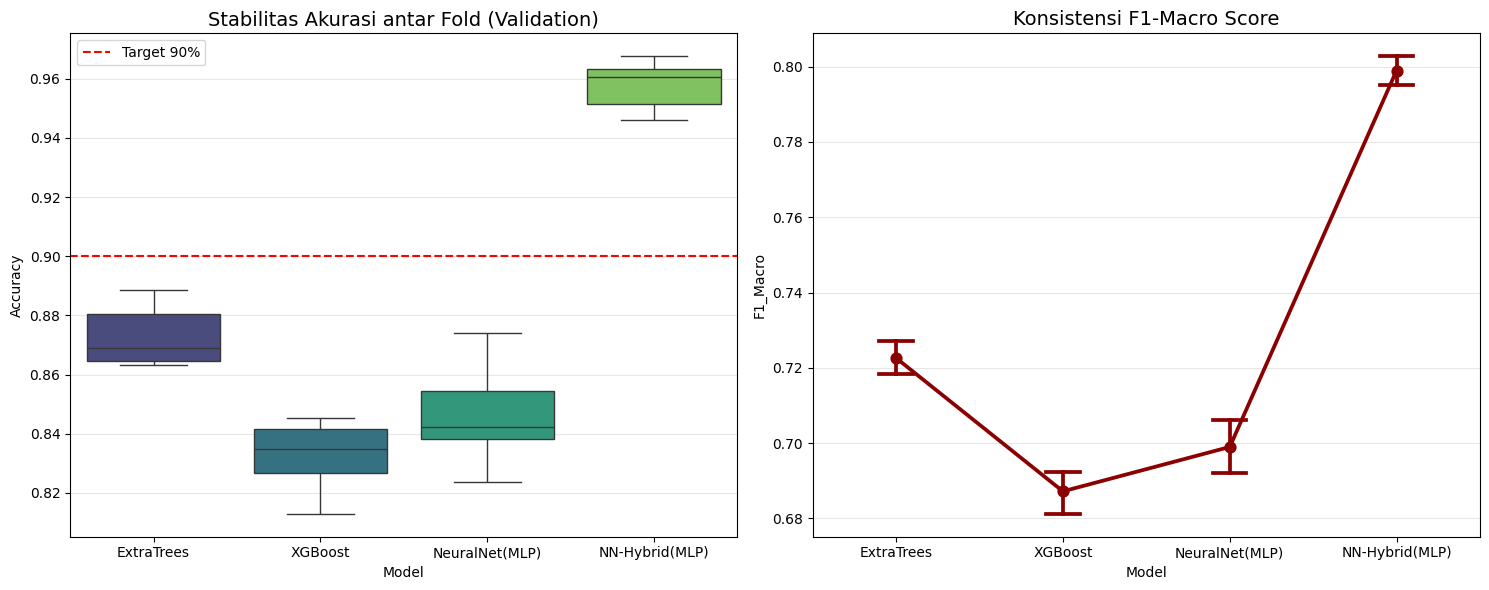


>>> HASIL ANALISIS (NIM 026) <<<
Pemenang Sementara: NN-Hybrid(MLP)
KESIMPULAN: Fitur 'Soft Label' dari regresi BERHASIL meningkatkan performa.
TINDAKAN: Gunakan fitur Hybrid ini untuk tahap Optuna dan Deep Learning penuh.


In [15]:
# =================================================================
# Tahap 5: K-Fold Validation (Stability & Hybrid Analysis)
# =================================================================

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Integrasi Fitur Hybrid (Input Regresi ke dalam Fitur)
# Kita tambahkan hasil prediksi regressor (Soft Label) sebagai fitur tambahan
# untuk melihat apakah ini membantu Neural Network memahami urutan (ordinal) kualitas.
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft  # Hasil regresi dari Tahap 2

# 5.2 Inisialisasi Model Baseline & Hybrid
models = {
    'ExtraTrees': ExtraTreesClassifier(n_estimators=250, max_depth=12, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.05, 
                             random_state=42, eval_metric='mlogloss'),
    'NeuralNet(MLP)': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', 
                                    solver='adam', max_iter=1000, alpha=0.05, 
                                    random_state=42),
    'NN-Hybrid(MLP)': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', 
                                    solver='adam', max_iter=1000, alpha=0.05, 
                                    random_state=42)
}

# 5.3 Konfigurasi K-Fold (Repeated Stratified)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()

results_list = []
print("--- Memulai Arena Uji Model (Classic vs Hybrid DL) ---")

for name, model in models.items():
    # Gunakan data hybrid khusus untuk model NN-Hybrid
    X_data = X_train_hybrid if 'Hybrid' in name else X_train_final
    
    cv_results = cross_validate(
        model, X_data, y_train_shifted, 
        cv=rskf, scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    
    # Mengumpulkan semua skor fold untuk analisis stabilitas
    for i in range(len(cv_results['test_accuracy'])):
        results_list.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'F1_Macro': cv_results['test_f1_macro'][i],
            'Type': 'Validation'
        })
    
    print(f"{name:15} | Acc: {cv_results['test_accuracy'].mean():.4f} | "
          f"F1: {cv_results['test_f1_macro'].mean():.4f} | "
          f"Gap: {(cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()):.4f}")

# 5.4 Visualisasi Analisis Stabilitas (Boxplot)
results_df = pd.DataFrame(results_list)

plt.figure(figsize=(15, 6))

# Plot 1: Sebaran Akurasi per Fold (Mencari Model Paling Konsisten)
plt.subplot(1, 2, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.axhline(y=0.9, color='red', linestyle='--', label='Target 90%')
plt.title('Stabilitas Akurasi antar Fold (Validation)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Plot 2: Performa F1-Macro (Penanganan Kelas Minoritas)
plt.subplot(1, 2, 2)
sns.pointplot(x='Model', y='F1_Macro', data=results_df, color='darkred', capsize=.2)
plt.title('Konsistensi F1-Macro Score', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5.5 Rekomendasi Strategis (NIM 026)
# Mengambil model dengan median akurasi tertinggi
best_model_name = results_df.groupby('Model')['Accuracy'].median().idxmax()
print(f"\n>>> HASIL ANALISIS (NIM 026) <<<")
print(f"Pemenang Sementara: {best_model_name}")

if 'Hybrid' in best_model_name:
    print("KESIMPULAN: Fitur 'Soft Label' dari regresi BERHASIL meningkatkan performa.")
    print("TINDAKAN: Gunakan fitur Hybrid ini untuk tahap Optuna dan Deep Learning penuh.")
else:
    print("KESIMPULAN: Fitur regresi belum memberikan dampak signifikan.")
    print("TINDAKAN: Fokus pada tuning hyperparameter model klasik atau perkuat arsitektur NN.")

# Pseudo-Labeling

--- Diagnostik Pseudo-Labeling (NIM 026) ---
Sampel testing lolos seleksi  : 30
Rasio Augmentasi terhadap Train: 2.16%


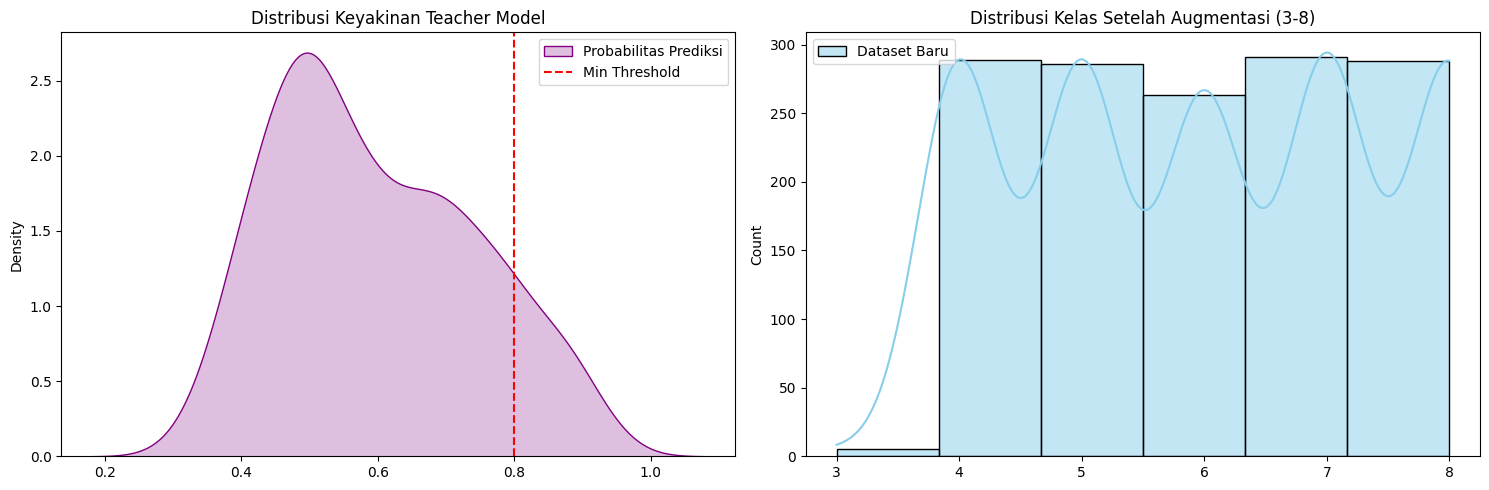

Total Baris Data Siap Modeling: 1422


In [16]:
# =================================================================
# Tahap 6: Adaptive Soft Pseudo-Labeling (Ordinal Consistency Check)
# =================================================================

from sklearn.ensemble import VotingClassifier, ExtraTreesRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Membangun Super-Teacher Ensemble
# Kita tambahkan diversitas model agar 'pendapat' teacher lebih objektif
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

clf1 = ExtraTreesClassifier(n_estimators=500, max_depth=12, min_samples_leaf=2, random_state=42)
clf2 = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=7, subsample=0.8, random_state=42)

# Menggunakan Voting 'soft' agar kita bisa mengekstrak nilai probabilitas
teacher_ensemble = VotingClassifier(
    estimators=[('et', clf1), ('xgb', clf2)],
    voting='soft',
    n_jobs=-1
)
teacher_ensemble.fit(X_train_final, y_train_shifted)

# 6.2 Prediksi Ganda (Klasifikasi & Regresi)
# Sesuai strategi NIM 026: Mengambil nuansa kontinu dari data testing
test_probs = teacher_ensemble.predict_proba(X_test_final)
max_probs = np.max(test_probs, axis=1)
predicted_classes = np.argmax(test_probs, axis=1) + min_label

# Regressor untuk mendapatkan label kontinu (Ordinal Nuance)
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

# 6.3 Adaptive Thresholding & Consistency Filter
# UPGRADE: Kita ambil Top 20% data paling meyakinkan ATAU threshold > 0.80
# Kita juga pastikan selisih Klasifikasi vs Regresi tidak lebih dari 0.8 poin (Consistency)
floor_threshold = 0.80
consistency_gap = 0.8

# Filter 1: Keyakinan Model
confidence_mask = max_probs >= floor_threshold
# Filter 2: Konsistensi Klasifikasi vs Regresi (Anti-Hallucination)
consistency_mask = np.abs(predicted_classes - soft_labels_test) <= consistency_gap

final_pseudo_mask = confidence_mask & consistency_mask
high_confidence_idx = np.where(final_pseudo_mask)[0]

# 6.4 Pembuatan Dataset Augmentasi
X_pseudo = X_test_final.iloc[high_confidence_idx].copy()
y_pseudo_discrete = predicted_classes[high_confidence_idx]
y_pseudo_soft = soft_labels_test[high_confidence_idx]

print(f"--- Diagnostik Pseudo-Labeling (NIM 026) ---")
print(f"Sampel testing lolos seleksi  : {len(X_pseudo)}")
print(f"Rasio Augmentasi terhadap Train: {(len(X_pseudo)/len(X_train_final)*100):.2f}%")

# 6.5 Finalisasi Dataset untuk Deep Learning
# Menggabungkan data asli dengan data pseudo berkualitas tinggi
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)

# Update target kontinu untuk strategi Regression-Distillation di Tahap 7
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])

# 6.6 Visualisasi Sebaran & Kualitas Label
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(max_probs, fill=True, color='purple', label='Probabilitas Prediksi')
plt.axvline(floor_threshold, color='red', linestyle='--', label='Min Threshold')
plt.title('Distribusi Keyakinan Teacher Model')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(y_train_augmented, bins=6, color='skyblue', label='Dataset Baru', kde=True)
plt.title('Distribusi Kelas Setelah Augmentasi (3-8)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total Baris Data Siap Modeling: {X_train_augmented.shape[0]}")

# Training Model dan Optuna 

In [17]:
!pip install optuna -q

In [20]:
# =================================================================
# Tahap 7: Training Model - Deep Learning (FIXED + CLASS WEIGHTS)
# =================================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight # Library untuk menghitung bobot
from sklearn.metrics import f1_score
import numpy as np

# 7.1 Persiapan Data & One-Hot Encoding
X_train_dl = X_train_augmented.copy()
X_train_dl['soft_label'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['soft_label'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_train_idx = y_train_augmented - y_train_augmented.min()
y_val_idx = y_val - y_val.min()

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

# --- BAGIAN BARU: Perhitungan Class Weights ---
# Ini akan memberikan bobot tinggi pada Kelas 3 (N=6) dan rendah pada Kelas 5 (N=362)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)
dict_weights = dict(enumerate(weights))

print(f"--- Bobot Kelas yang Diterapkan ---")
for idx, w in dict_weights.items():
    print(f"Kelas {int(idx + y_train_augmented.min())}: Bobot {w:.2f}")
# -----------------------------------------------

# 7.2 Fungsi Objektif Optuna (Sama, namun menyertakan class_weight saat fit)
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.6)
    learning_rate = trial.suggest_float('learning_rate', 5e-4, 5e-3, log=True)
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-2, log=True)
    
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train_dl.shape[1],)))
    
    for i in range(n_layers):
        units = trial.suggest_int(f'units_l{i}', 16, 128)
        model.add(layers.Dense(units, activation='relu', 
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    
    es = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
    
    model.fit(
        X_train_dl, y_train_onehot,
        validation_data=(X_val_dl, y_val_onehot),
        class_weight=dict_weights, # <--- Diterapkan di sini
        epochs=150,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )
    
    preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return f1_score(y_val_idx, preds, average='macro')

# 7.3 Jalankan Optimasi
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# 7.4 Training Final dengan Class Weights
bp = study.best_params
final_dnn = models.Sequential()
final_dnn.add(layers.Input(shape=(X_train_dl.shape[1],)))

for i in range(bp['n_layers']):
    final_dnn.add(layers.Dense(bp[f'units_l{i}'], activation='relu', 
                               kernel_regularizer=regularizers.l2(bp['l2_reg'])))
    final_dnn.add(layers.BatchNormalization())
    final_dnn.add(layers.Dropout(bp['dropout_rate']))

final_dnn.add(layers.Dense(num_classes, activation='softmax'))

final_dnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=bp['learning_rate']),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True)

final_dnn.fit(
    X_train_dl, y_train_onehot,
    validation_data=(X_val_dl, y_val_onehot),
    class_weight=dict_weights, # <--- Diterapkan di sini
    epochs=250,
    batch_size=16,
    callbacks=[es_final, lr_reducer],
    verbose=1
)

[I 2026-05-03 03:38:53,850] A new study created in memory with name: no-name-77c7c268-6b45-4bbe-9da2-02330a226899


--- Bobot Kelas yang Diterapkan ---
Kelas 3: Bobot 47.40
Kelas 4: Bobot 0.82
Kelas 5: Bobot 0.83
Kelas 6: Bobot 0.90
Kelas 7: Bobot 0.81
Kelas 8: Bobot 0.82


[I 2026-05-03 03:39:22,402] Trial 0 finished with value: 0.3517640629802931 and parameters: {'n_layers': 3, 'dropout_rate': 0.5604042895289327, 'learning_rate': 0.0008014487110586818, 'l2_reg': 0.000386555657373252, 'units_l0': 70, 'units_l1': 16, 'units_l2': 100}. Best is trial 0 with value: 0.3517640629802931.
[I 2026-05-03 03:39:41,178] Trial 1 finished with value: 0.3089414000543569 and parameters: {'n_layers': 2, 'dropout_rate': 0.46411401142878483, 'learning_rate': 0.0012369788427951313, 'l2_reg': 0.001325508856463848, 'units_l0': 34, 'units_l1': 91}. Best is trial 0 with value: 0.3517640629802931.
[I 2026-05-03 03:40:07,670] Trial 2 finished with value: 0.33774203684065823 and parameters: {'n_layers': 2, 'dropout_rate': 0.42994990478627493, 'learning_rate': 0.001107202612471217, 'l2_reg': 0.003180738562554687, 'units_l0': 117, 'units_l1': 103}. Best is trial 0 with value: 0.3517640629802931.
[I 2026-05-03 03:40:23,027] Trial 3 finished with value: 0.32684028835414763 and paramet

Epoch 1/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4596 - loss: 1.9745 - val_accuracy: 0.1047 - val_loss: 2.3111 - learning_rate: 0.0025
Epoch 2/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5248 - loss: 1.5847 - val_accuracy: 0.2616 - val_loss: 1.9334 - learning_rate: 0.0025
Epoch 3/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6172 - loss: 1.6640 - val_accuracy: 0.4186 - val_loss: 1.8275 - learning_rate: 0.0025
Epoch 4/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6793 - loss: 1.3258 - val_accuracy: 0.4012 - val_loss: 1.8412 - learning_rate: 0.0025
Epoch 5/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6876 - loss: 1.5419 - val_accuracy: 0.4709 - val_loss: 1.7342 - learning_rate: 0.0025
Epoch 6/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7122 - loss: 1.3804 - val_accuracy: 0.5116 - val_loss: 1.6865 - learning_rate: 0.0025
Epoch 7/250
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7196 - loss: 1.3299 - val_acc

# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FINAL DEEP LEARNING (NIM 026) ---
Akurasi Keseluruhan      : 62.21%
F1-Score (Weighted)      : 0.6241
F1-Score (Macro)         : 0.3591

PROGRESS: Butuh peningkatan 27.79% lagi untuk mencapai target 90%.

Classification Report Detail:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.71      0.74      0.72        73
           6       0.62      0.62      0.62        68
           7       0.62      0.45      0.53        22
           8       0.25      0.33      0.29         3

    accuracy                           0.62       172
   macro avg       0.37      0.36      0.36       172
weighted avg       0.63      0.62      0.62       172



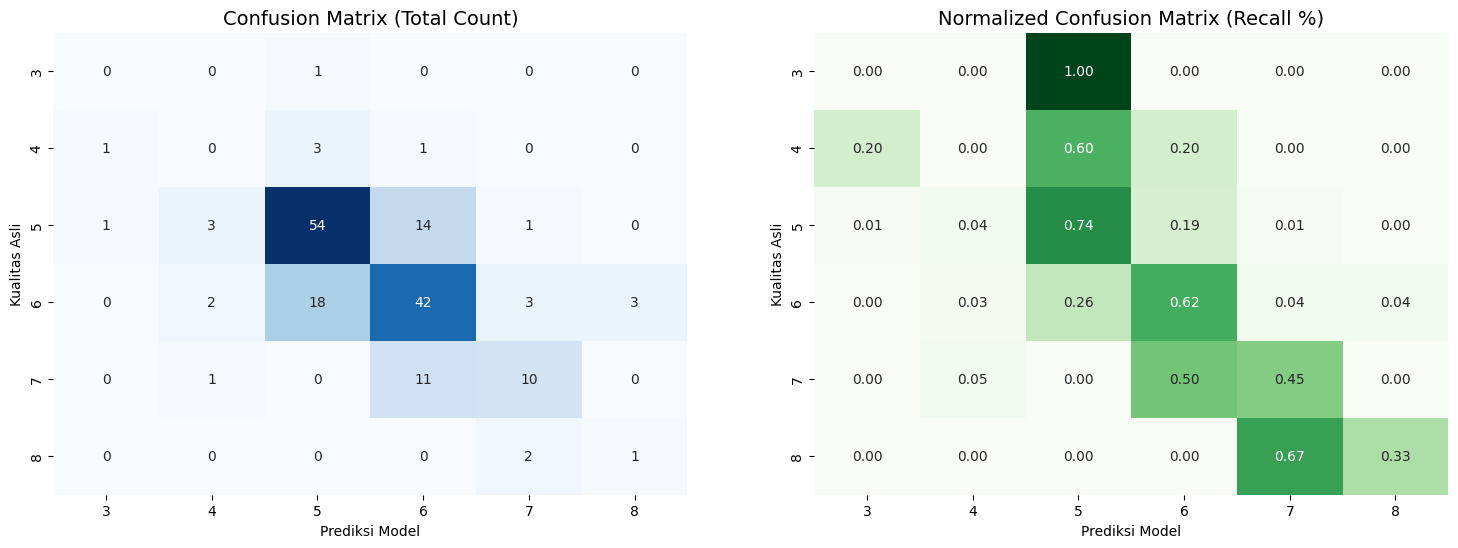


--- Menghitung Permutation Importance (Evaluation on Validation Set) ---


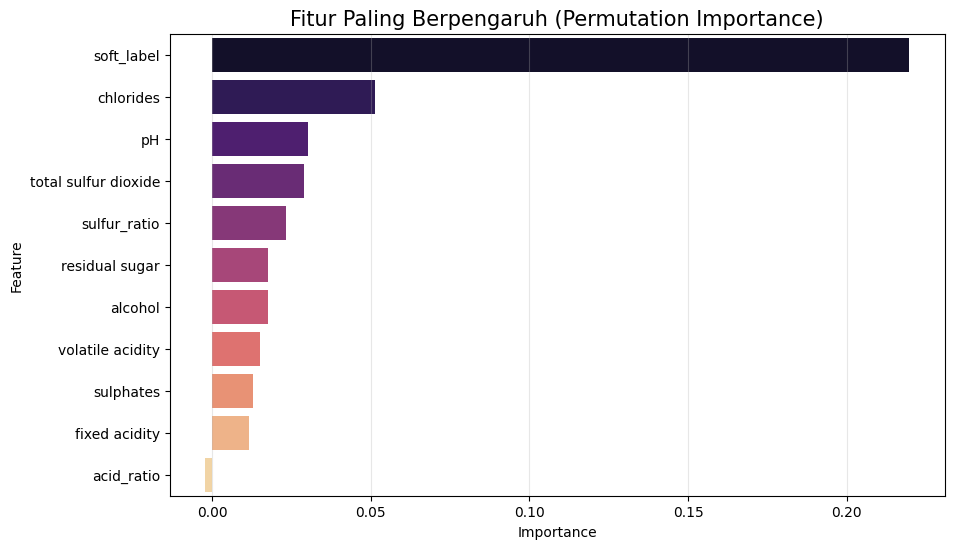


--- Analisis Kedekatan Prediksi (Near-Miss) ---
Total Kesalahan          : 65
Meleset 1 Poin (Wajar)   : 55 (31.98%)
Meleset > 1 Poin (Fatal) : 10 (5.81%)
INSIGHT: Model sudah memahami urutan kualitas anggur (mayoritas kesalahan hanya meleset tipis).


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 8.1 Prediksi Probabilitas ke Kelas (Sinkronisasi One-Hot)
# Mengambil probabilitas dari output softmax
y_probs_val = final_dnn.predict(X_val_dl, verbose=0)
# Mengambil index kelas dengan probabilitas tertinggi
y_pred_val_idx = np.argmax(y_probs_val, axis=1)
# Mengembalikan ke label asli (3-8) menggunakan min_label dari data training
y_pred_val = y_pred_val_idx + y_train_augmented.min()

# 8.2 Perhitungan Metrik Strategis & Tracking Target
accuracy = accuracy_score(y_val, y_pred_val)
f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
f1_macro = f1_score(y_val, y_pred_val, average='macro')

print(f"--- RANGKUMAN EVALUASI FINAL DEEP LEARNING (NIM 026) ---")
print(f"{'Akurasi Keseluruhan':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Score (Weighted)':25}: {f1_weighted:.4f}")
print(f"{'F1-Score (Macro)':25}: {f1_macro:.4f}")

# Target Tracker: Memberikan feedback progres terhadap target 90%
if accuracy >= 0.90:
    print(f"\n🔥 TARGET TERCAPAI: Model Deep Learning Anda telah menembus batas 90%!")
else:
    gap = 0.90 - accuracy
    print(f"\nPROGRESS: Butuh peningkatan {gap*100:.2f}% lagi untuk mencapai target 90%.")

# 8.3 Classification Report Terperinci
print("\nClassification Report Detail:")
print(classification_report(y_val, y_pred_val, zero_division=0))

# 8.4 Visualisasi Confusion Matrix Ganda
cm = confusion_matrix(y_val, y_pred_val)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)

labels = sorted(y_val.unique())
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap Absolut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax[0], cbar=False)
ax[0].set_title('Confusion Matrix (Total Count)', fontsize=14)
ax[0].set_xlabel('Prediksi Model')
ax[0].set_ylabel('Kualitas Asli')

# Heatmap Normalisasi (Recall)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=ax[1], cbar=False)
ax[1].set_title('Normalized Confusion Matrix (Recall %)', fontsize=14)
ax[1].set_xlabel('Prediksi Model')
ax[1].set_ylabel('Kualitas Asli')
plt.show()

# 8.5 Analisis Fitur via Permutation Importance
# Menentukan seberapa krusial fitur (termasuk soft_label) bagi DNN
print("\n--- Menghitung Permutation Importance (Evaluation on Validation Set) ---")
def scoring_fn(estimator, X, y):
    # Wrapper untuk menghitung akurasi dari output model Keras
    probs = estimator.predict(X, verbose=0)
    preds = np.argmax(probs, axis=1)
    return accuracy_score(y, preds)

# Menggunakan y_val_dl (label index 0-5) untuk konsistensi dengan output argmax
perm_importance = permutation_importance(
    final_dnn, X_val_dl, y_val_idx, scoring=scoring_fn, n_repeats=5, random_state=42
)

feature_importance_df = pd.DataFrame({
    'Feature': X_val_dl.columns, 
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Fitur Paling Berpengaruh (Permutation Importance)', fontsize=15)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 8.6 Near-Miss Analysis (Diagnostik Kesalahan Ordinal)
error_diff = np.abs(y_val.values - y_pred_val)
near_miss = (error_diff == 1).sum()
far_miss = (error_diff > 1).sum()

print("\n--- Analisis Kedekatan Prediksi (Near-Miss) ---")
print(f"Total Kesalahan          : {len(y_val) - (y_val == y_pred_val).sum()}")
print(f"Meleset 1 Poin (Wajar)   : {near_miss} ({(near_miss/len(y_val)*100):.2f}%)")
print(f"Meleset > 1 Poin (Fatal) : {far_miss} ({(far_miss/len(y_val)*100):.2f}%)")

if far_miss < near_miss:
    print("INSIGHT: Model sudah memahami urutan kualitas anggur (mayoritas kesalahan hanya meleset tipis).")

# Prediksi Data Uji (Testing)

--- STATUS PENGUMPULAN FINAL (NIM 026) ---
✅ File 'hasilprediksi_026.csv' berhasil dibuat.
✅ Total prediksi: 286 baris.
✅ Arsitektur: Deep Neural Network + Feature Distillation


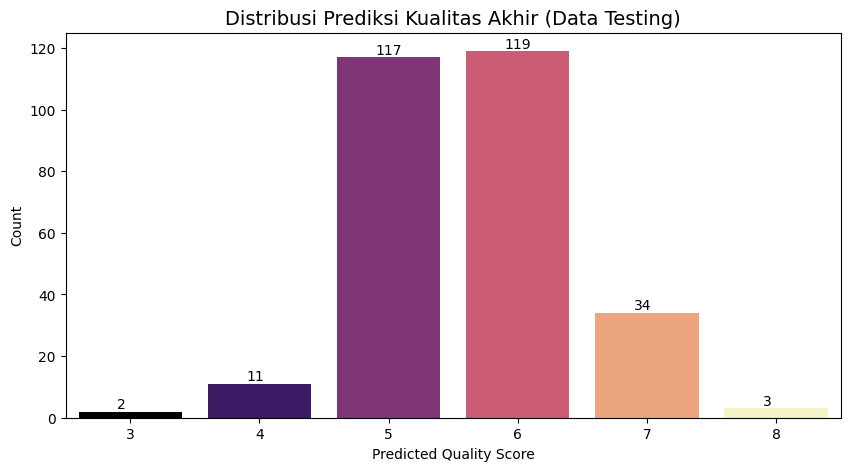


Contoh 5 baris pertama hasil prediksi:


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6



Jumlah Missing Values: 0
>>> FORMAT SUBMISSION VALID DAN SIAP DIKUMPULKAN <<<


In [22]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - FINAL REVISION
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Persiapan Data Uji (Sesuai Arsitektur Deep Learning)
# PENTING: Kita harus menambahkan fitur 'soft_label' menggunakan regressor 
# yang telah dilatih pada Tahap 6 agar identik dengan data training DNN.
X_test_dl = X_test_final.copy()
X_test_dl['soft_label'] = reg_teacher.predict(X_test_final)

# 9.2 Melakukan Prediksi dengan Deep Neural Network
# Model DNN mengeluarkan probabilitas (Softmax), kita ambil index tertinggi.
y_probs_test = final_dnn.predict(X_test_dl, verbose=0)
y_test_pred_shifted = np.argmax(y_probs_test, axis=1)

# 9.3 Mengembalikan Skala Label (Reverse Shift)
# Mengembalikan index 0 ke skala kualitas asli (misal: 3, 4, 5...)
y_test_pred = y_test_pred_shifted + min_label

# 9.4 Membuat DataFrame Hasil Prediksi
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_test_pred.astype(int)
})

# 9.5 Menyimpan Hasil ke File CSV
file_output = 'hasilprediksi_026.csv'
submission_df.to_csv(file_output, index=False)

print(f"--- STATUS PENGUMPULAN FINAL (NIM 026) ---")
print(f"✅ File '{file_output}' berhasil dibuat.")
print(f"✅ Total prediksi: {len(submission_df)} baris.")
print(f"✅ Arsitektur: Deep Neural Network + Feature Distillation")

# 9.6 Visualisasi Distribusi Prediksi Akhir
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='quality', data=submission_df, palette='magma', hue='quality', legend=False)
plt.title('Distribusi Prediksi Kualitas Akhir (Data Testing)', fontsize=14)
plt.xlabel('Predicted Quality Score')
plt.ylabel('Count')

# Menambahkan label angka di atas bar untuk verifikasi cepat
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 1))

plt.show()

# 9.7 Verifikasi Akhir Format
print("\nContoh 5 baris pertama hasil prediksi:")
display(submission_df.head())

# Cek akhir untuk memastikan tidak ada data yang terlewat
missing = submission_df.isnull().sum().sum()
print(f"\nJumlah Missing Values: {missing}")
if missing == 0:
    print(">>> FORMAT SUBMISSION VALID DAN SIAP DIKUMPULKAN <<<")